1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. Genere una variable binaria para indicar quienes dieron el test. Justifique su proceso.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col
import missingno as msno 

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

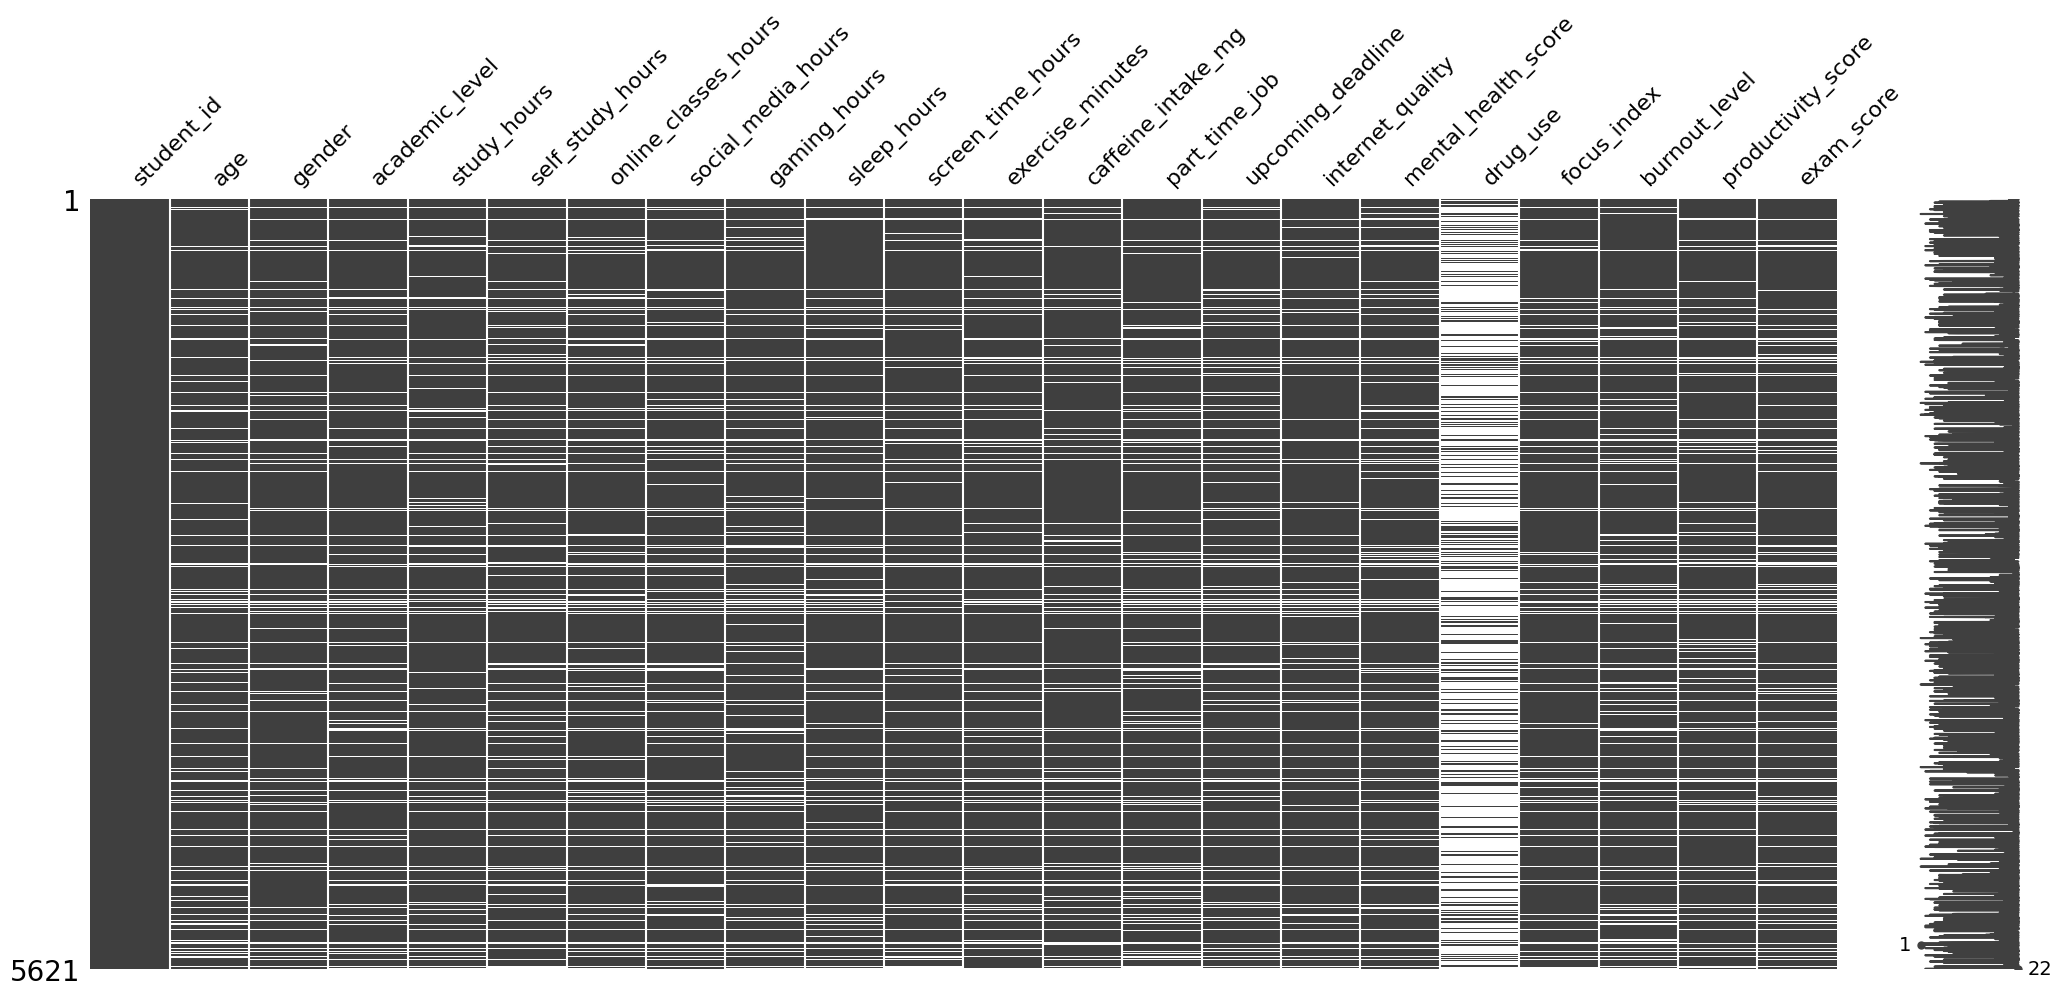

=== Valores faltantes por columna ===
                      missing_count  missing_pct
drug_use                       4103        72.99
upcoming_deadline               717        12.76
burnout_level                   716        12.74
exam_score                      709        12.61
part_time_job                   703        12.51
online_classes_hours            682        12.13
mental_health_score             675        12.01
self_study_hours                667        11.87
social_media_hours              656        11.67
gaming_hours                    656        11.67
age                             648        11.53
productivity_score              638        11.35
focus_index                     633        11.26
academic_level                  630        11.21
caffeine_intake_mg              600        10.67
exercise_minutes                599        10.66
screen_time_hours               586        10.43
study_hours                     574        10.21
gender                         

In [2]:
df = pd.read_csv('student_productivity.csv')
msno.matrix(df)
plt.show()
# Porcentaje de NaN por columna
nan_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

print("=== Valores faltantes por columna ===")
print(nan_summary[nan_summary['missing_count'] > 0])
print(f"\nTotal filas: {len(df)}")

In [3]:
# Se reemplazan todas las variables categóricas, incluyendo todos los valores de género
df.replace({
    'internet_quality': {'Poor': 1, 'Average': 2, 'Good': 3},
    'academic_level':   {'High School': 1, 'High School ': 1, 'Undergraduate': 2, 'Undergraduate ': 2, 'Postgraduate': 3, 'Postgraduate ': 3},
    'part_time_job':    {'no': 0, 'No': 0, 'yes': 1, 'Yes': 1},
    'gender':           {'Female': 0, 'Female ': 0, 'Male': 1, 'Male ': 1, 'Other': 2, 'Other ': 2}
}, inplace=True)


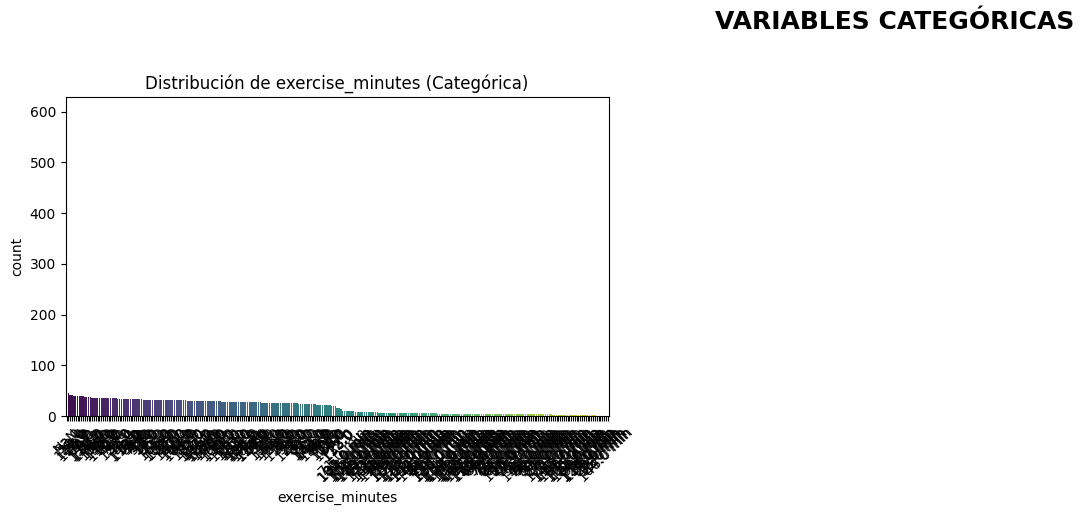

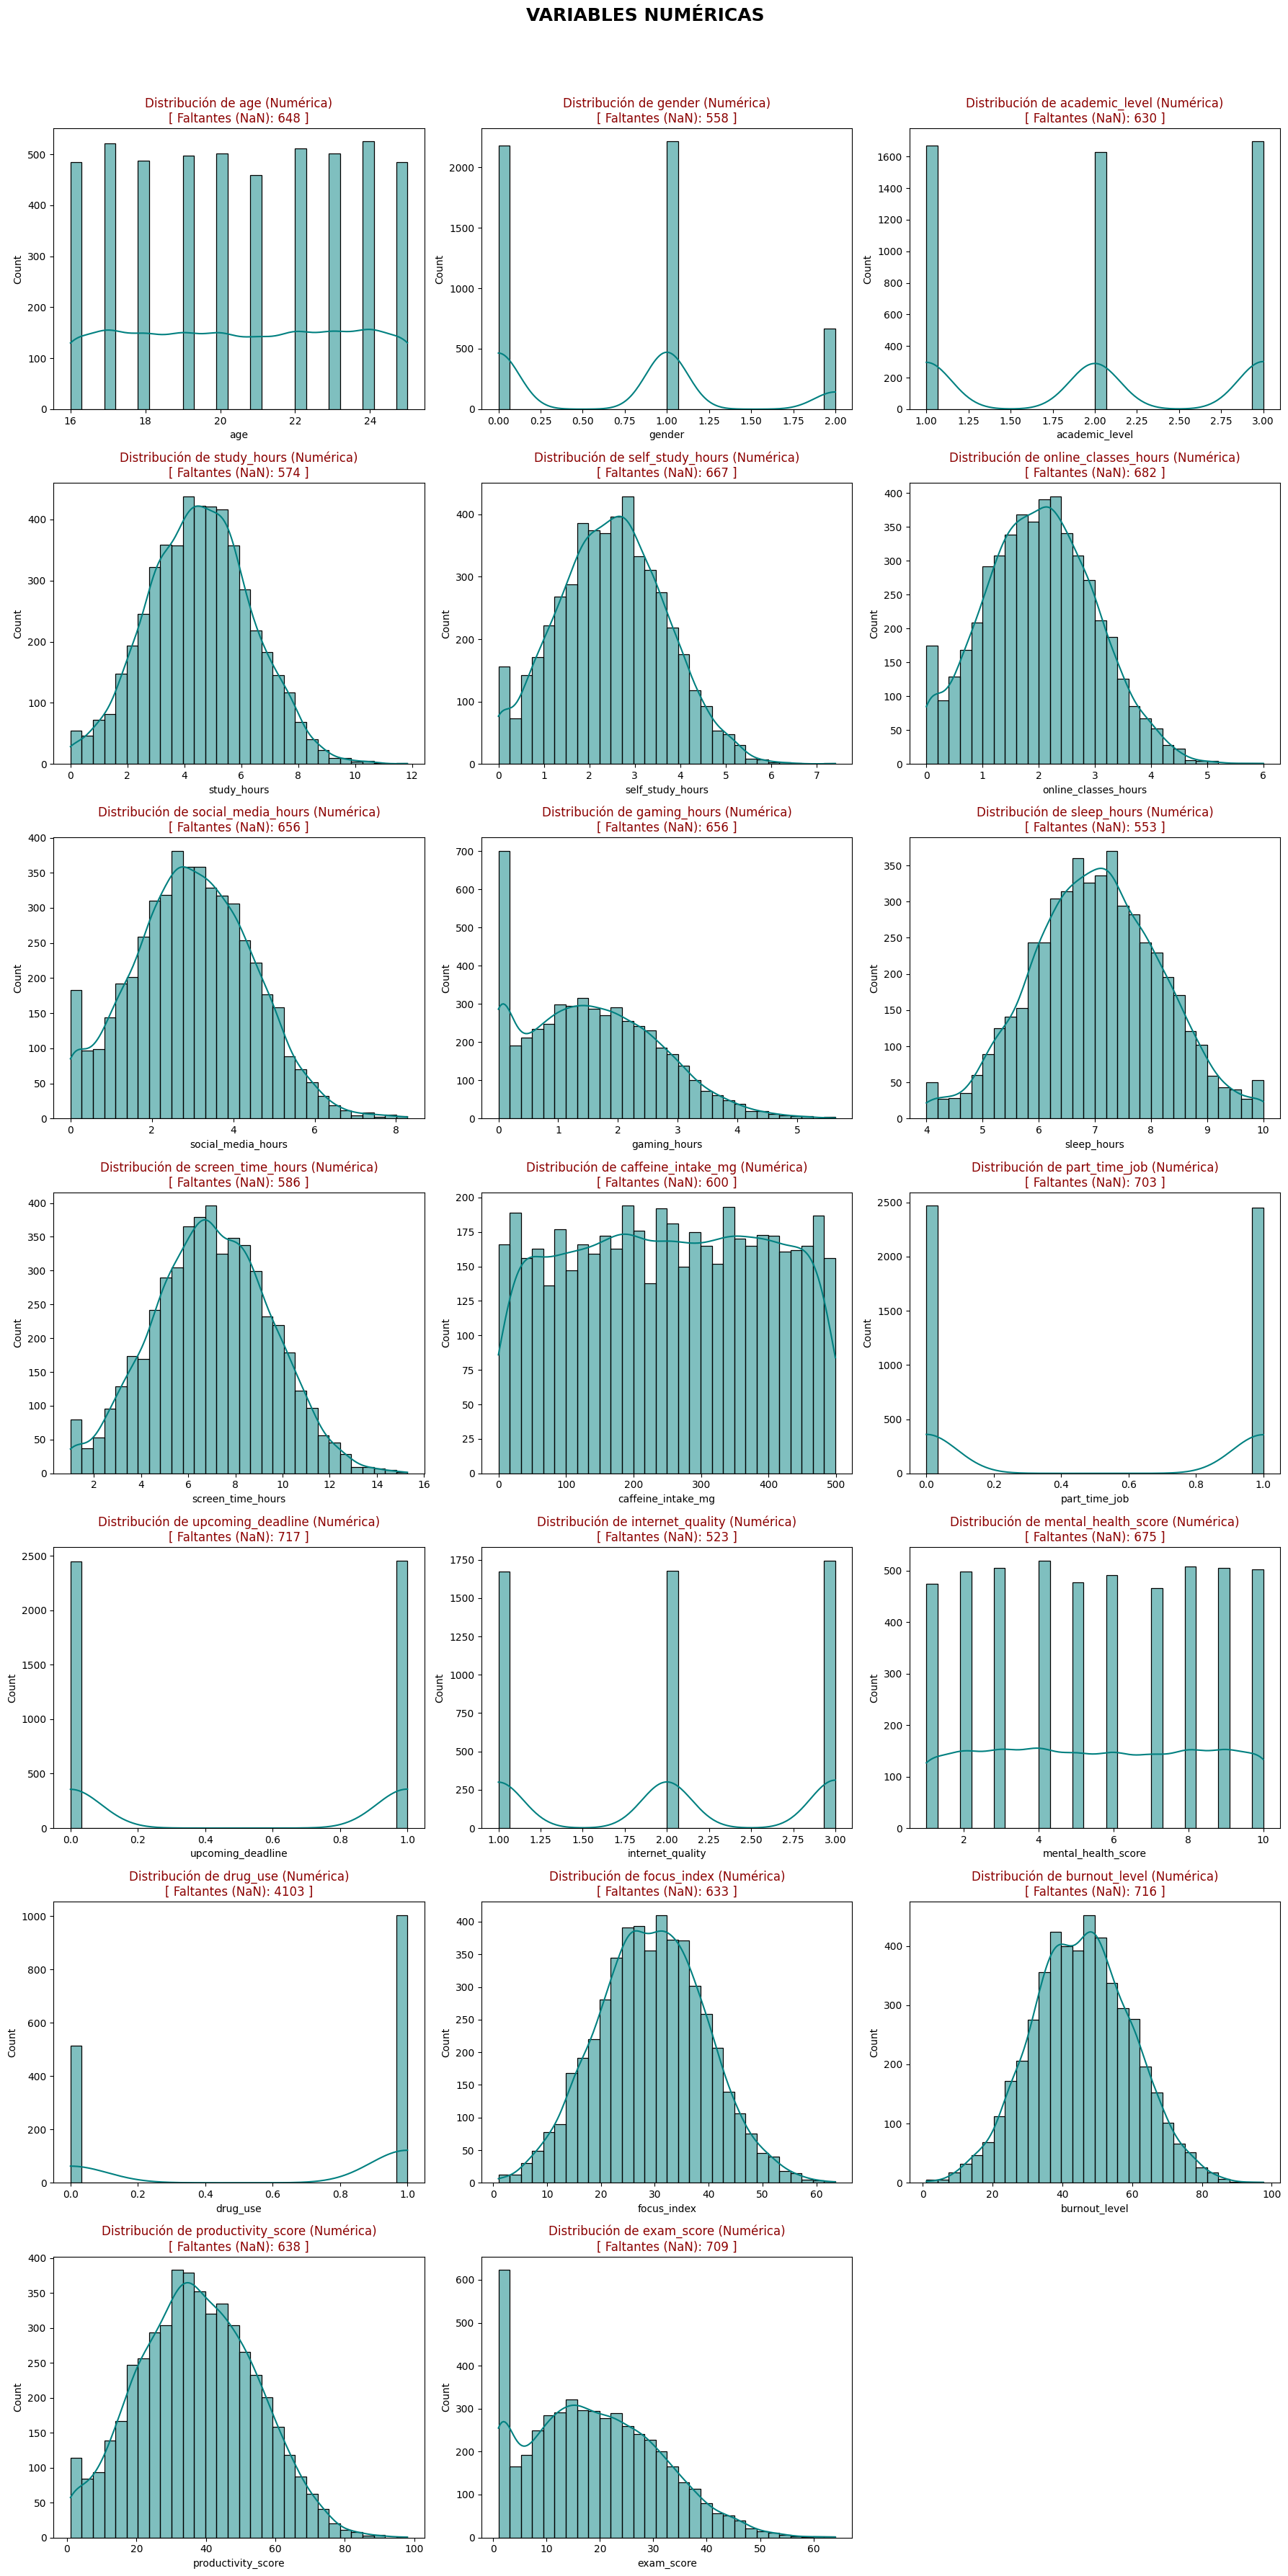

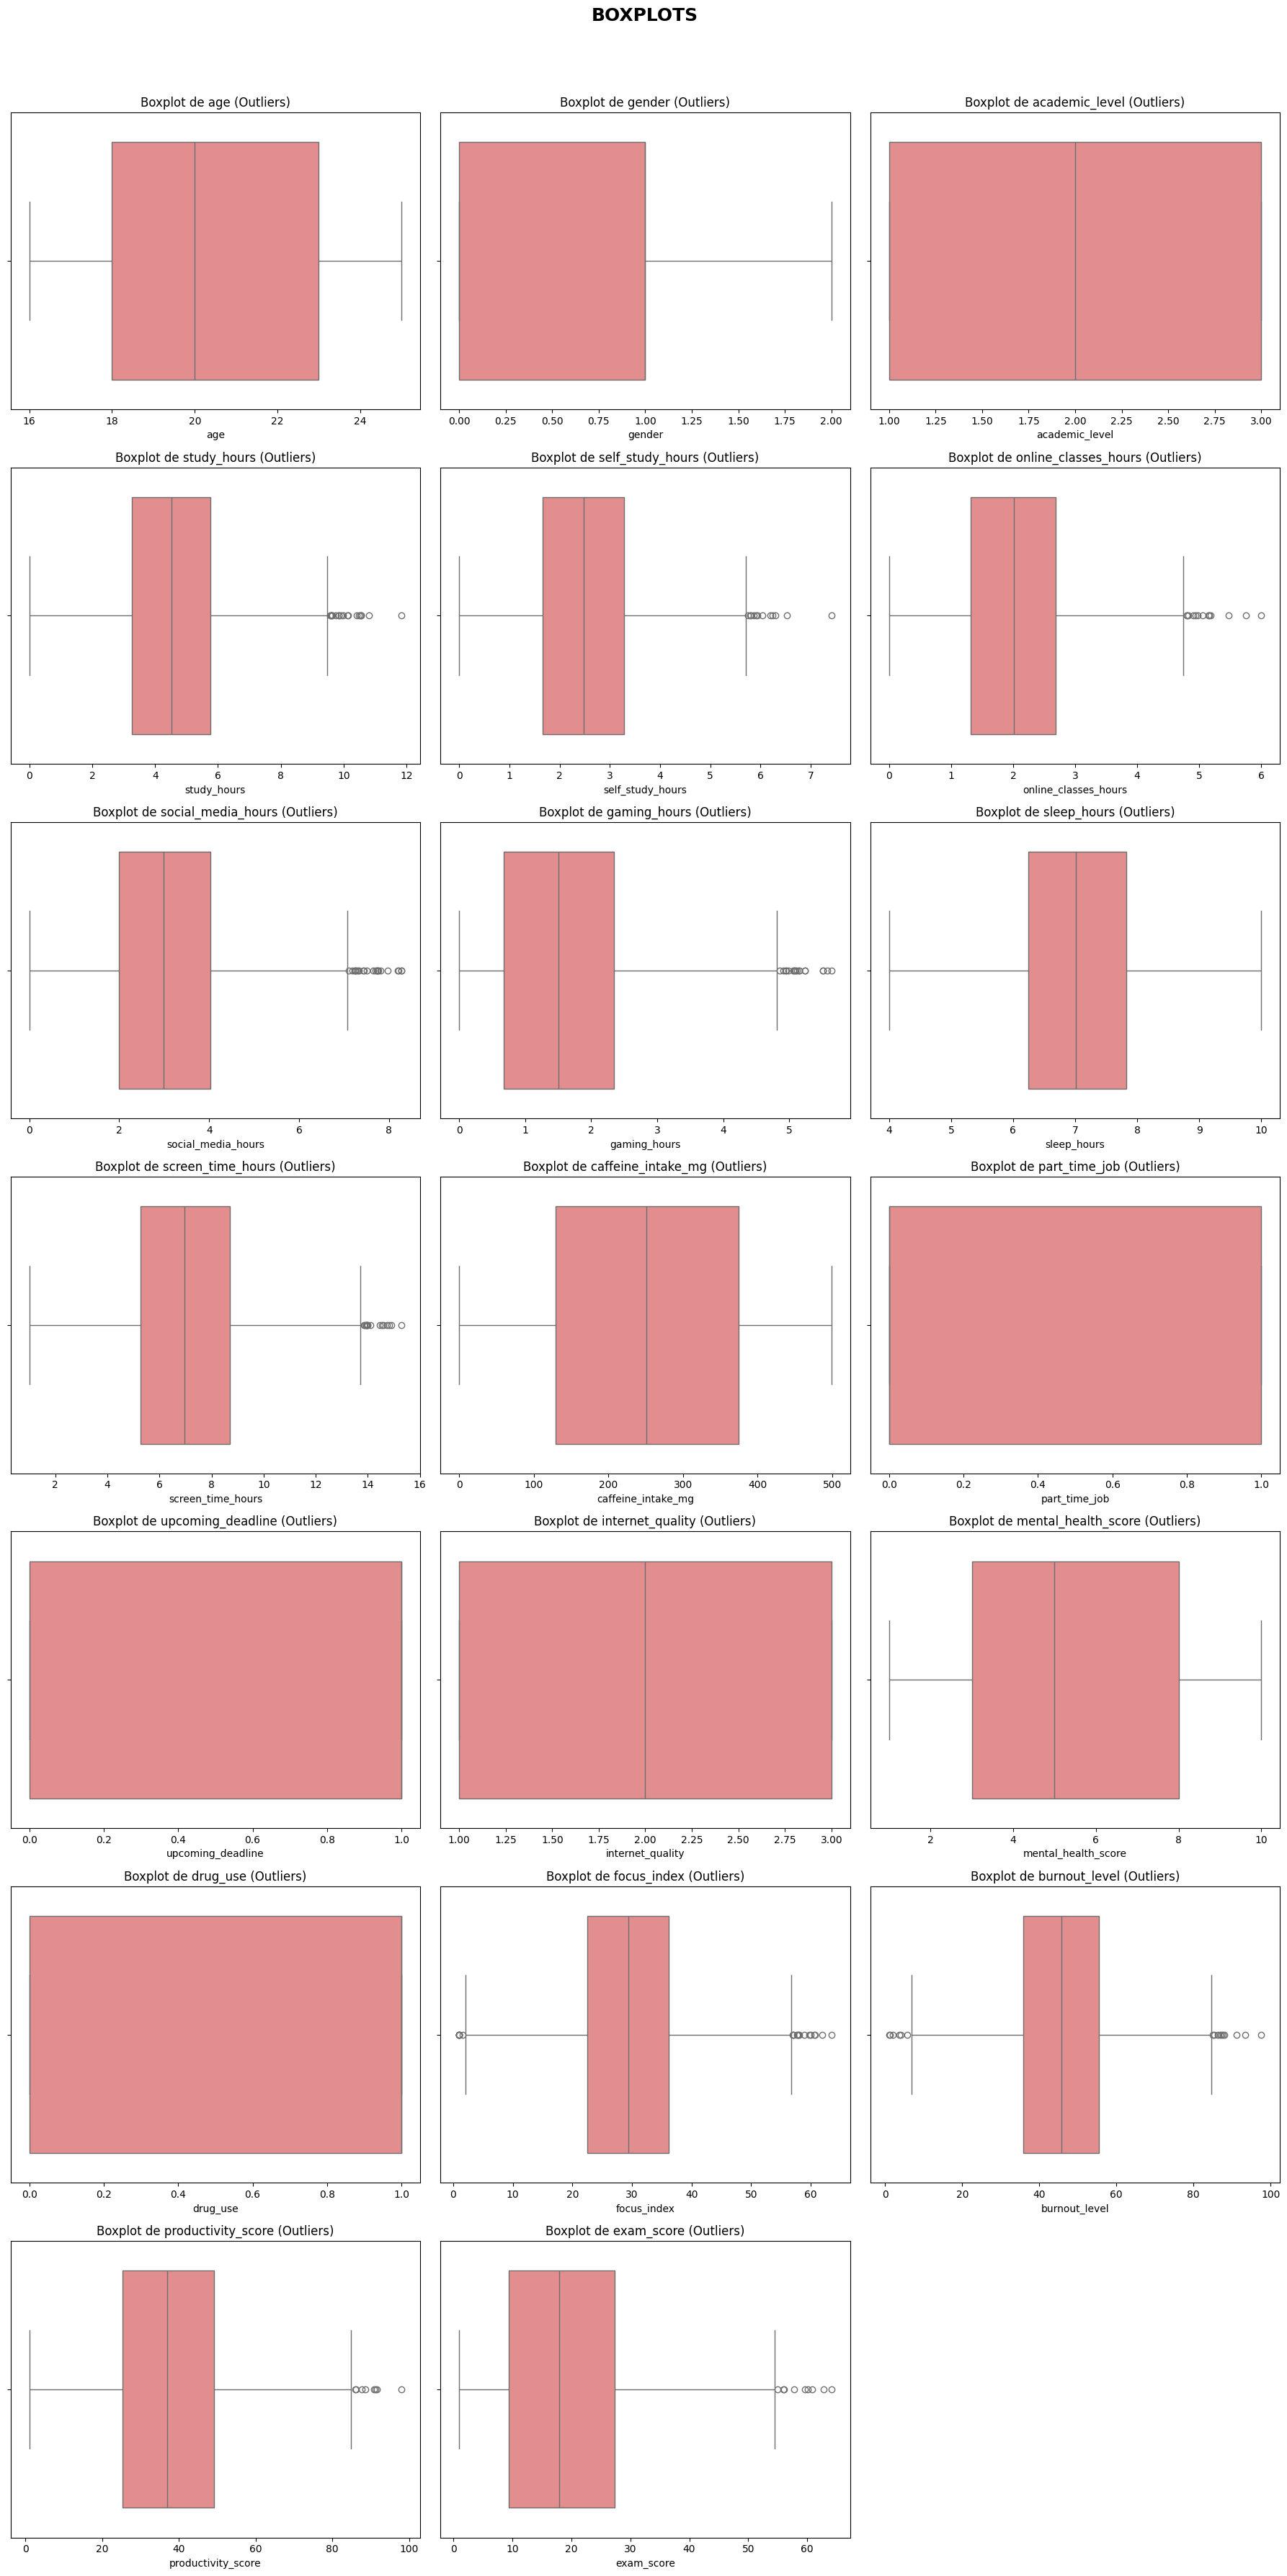

In [4]:
# ============================================================
# VISUALIZACIÓN DE VARIABLES 
# ============================================================

# Se excluye 'student_id' por ser un identificador
cols_to_plot = [col for col in df.columns if col != 'student_id']

# Separar columnas categóricas y numéricas
cat_cols = [col for col in cols_to_plot if df[col].dtype == 'object']
num_cols = [col for col in cols_to_plot if df[col].dtype != 'object']

n_cols = 3

# ------------------------------------------------------------
# Gráficos para Variables Categóricas
# ------------------------------------------------------------
n_rows_cat = (len(cat_cols) + n_cols - 1) // n_cols

fig_cat, axes_cat = plt.subplots(n_rows_cat, n_cols, figsize=(18, 5 * n_rows_cat))
axes_cat = axes_cat.flatten()

for i, col in enumerate(cat_cols):
    ax = axes_cat[i]
    
    # Rellenamos los NaN con el texto 'NaN' para que genere una barra
    plot_data = df[col].fillna('NaN')
    
    sns.countplot(x=plot_data, ax=ax, palette='viridis', order=plot_data.value_counts().index)
    ax.set_title(f"Distribución de {col} (Categórica)", fontsize=12)
    ax.tick_params(axis='x', rotation=45)

# Ocultar subplots vacíos si los hay
for j in range(len(cat_cols), len(axes_cat)):
    fig_cat.delaxes(axes_cat[j])

fig_cat.suptitle('VARIABLES CATEGÓRICAS', fontsize=18, fontweight='bold', y=1.02)
fig_cat.tight_layout()
plt.show()


# ------------------------------------------------------------
# Gráficos para Variables Numéricas 
# ------------------------------------------------------------
n_rows_num = (len(num_cols) + n_cols - 1) // n_cols

fig_num, axes_num = plt.subplots(n_rows_num, n_cols, figsize=(18, 5 * n_rows_num))
axes_num = axes_num.flatten()

for i, col in enumerate(num_cols):
    ax = axes_num[i]
    
    sns.histplot(data=df, x=col, kde=True, ax=ax, color='teal', bins=30)
    
    # Calculamos la cantidad de NaNs y lo agregamos al título de forma destacada
    nan_count = df[col].isna().sum()
    ax.set_title(f"Distribución de {col} (Numérica)\n[ Faltantes (NaN): {nan_count} ]", 
                 fontsize=12, color='darkred' if nan_count > 0 else 'black')

# Ocultar subplots vacíos si los hay
for j in range(len(num_cols), len(axes_num)):
    fig_num.delaxes(axes_num[j])

fig_num.suptitle('VARIABLES NUMÉRICAS', fontsize=18, fontweight='bold', y=1.02)
fig_num.tight_layout()
plt.show()


# ------------------------------------------------------------
# Gráficos de Caja (Boxplots)
# ------------------------------------------------------------
fig_box, axes_box = plt.subplots(n_rows_num, n_cols, figsize=(18, 5 * n_rows_num))
axes_box = axes_box.flatten()

for i, col in enumerate(num_cols):
    ax = axes_box[i]
    
    # Boxplot para visualizar valores atípicos
    sns.boxplot(data=df, x=col, ax=ax, color='lightcoral')
    ax.set_title(f"Boxplot de {col} (Outliers)", fontsize=12)

# Ocultar subplots vacíos si los hay
for j in range(len(num_cols), len(axes_box)):
    fig_box.delaxes(axes_box[j])

fig_box.suptitle('BOXPLOTS', fontsize=18, fontweight='bold', y=1.02)
fig_box.tight_layout()
plt.show()


✅ Limpieza completada.
Dimensiones finales: (4818, 22)

Total de NaNs restantes (debería ser solo exam_score):
Series([], dtype: int64)


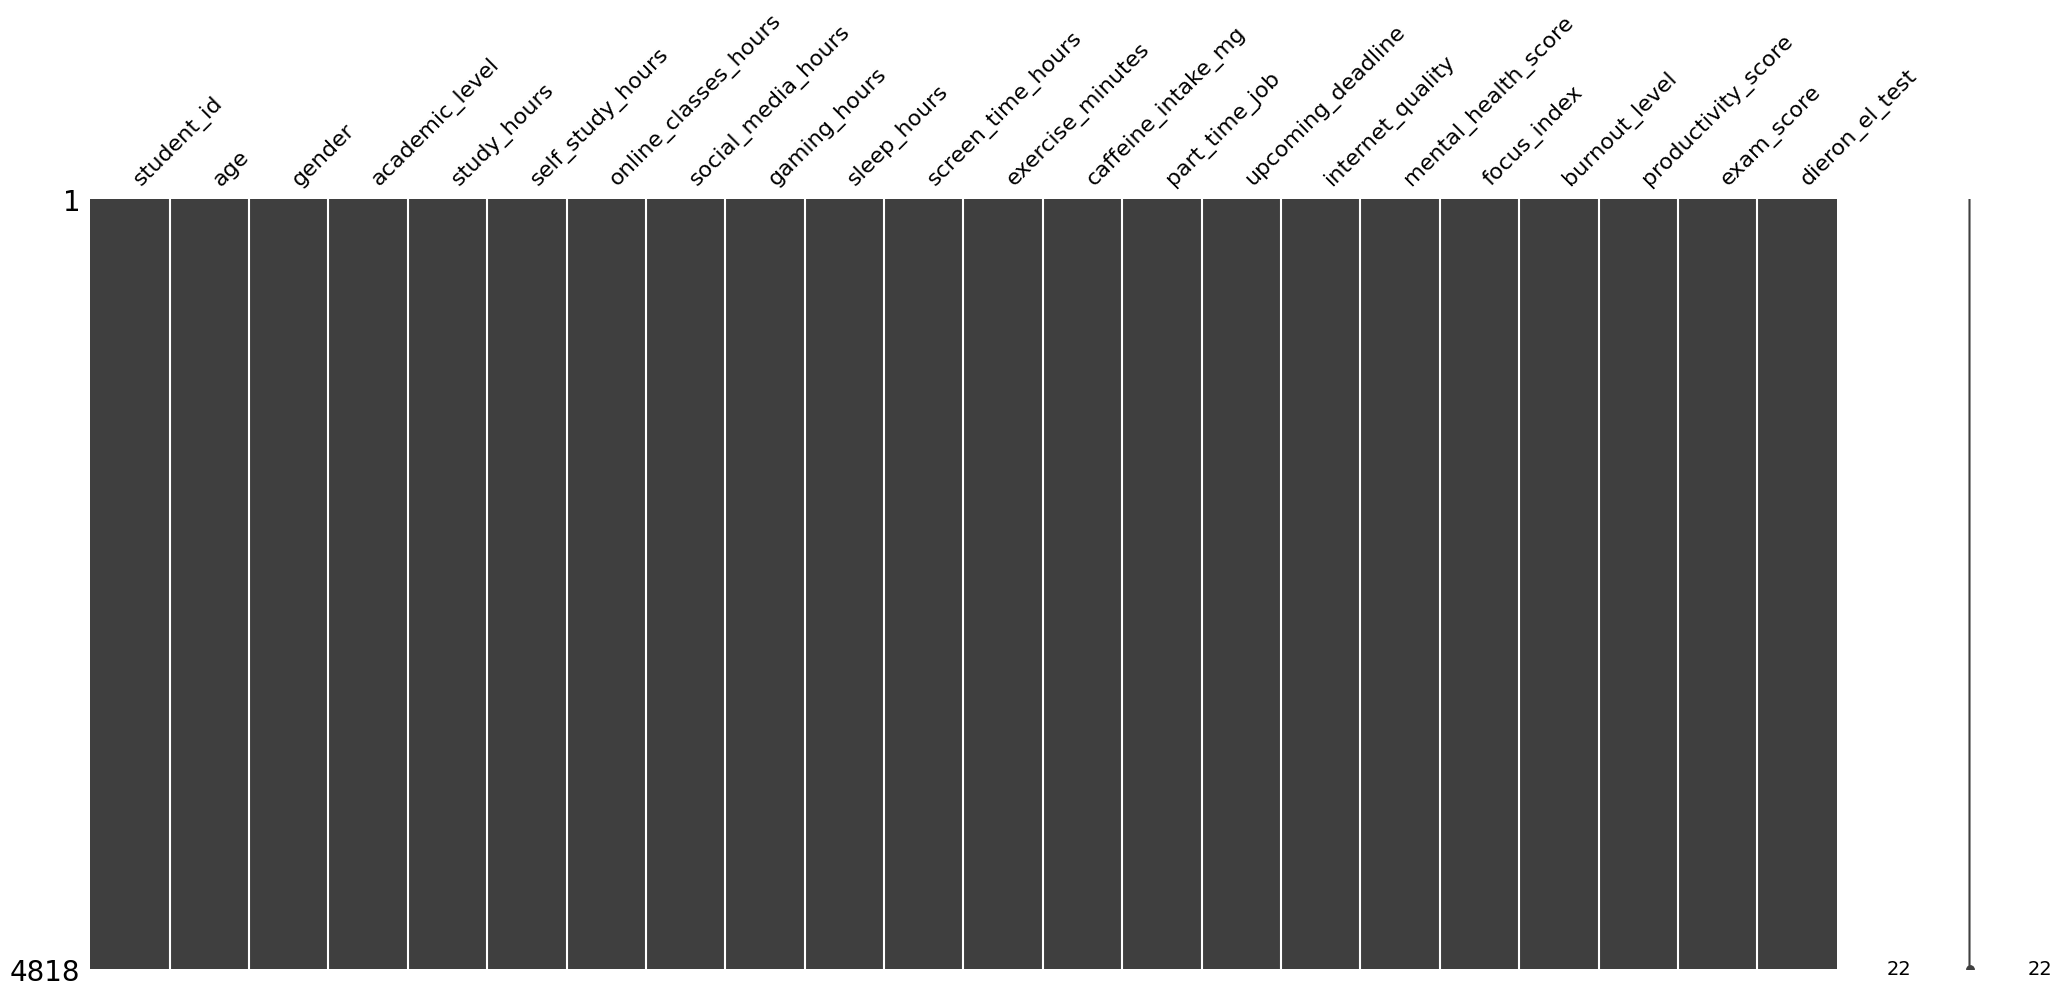

In [5]:
# ============================================================
# LIMPIEZA DE DATOS
# ============================================================

# Creamos la variable binaria
df['dieron_el_test'] = df['exam_score'].notnull().astype(int)

# Eliminar filas casi vacías (>50% de las columnas con datos NaNs)
df.dropna(thresh=11, inplace=True)

# Eliminar columna 'drug_use' por exceso de NaNs
if 'drug_use' in df.columns:
    df.drop(columns=['drug_use'], inplace=True)

# ESTANDARIZACIÓN DE TEXTO Y TIPOS DE DATOS
if df['exercise_minutes'].dtype == 'object':
    df['exercise_minutes'] = df['exercise_minutes'].str.replace(' min', '', regex=False).astype(float)

# Filtrar edades imposibles (menores a 10 o mayores a 60 años) y convertirlas a NaN temporalmente
df.loc[(df['age'] < 10) | (df['age'] > 60), 'age'] = np.nan

# Imputar Moda en Categóricas y Mediana en Numéricas
for col in df.columns:
    if col != 'exam_score': # Dejamos exam_score intacto para no distorsionar quién dio la prueba
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)
#Eliminamos las filas sin variable dependiente
df.dropna(subset=['exam_score'], inplace=True)

print("✅ Limpieza completada.")
print(f"Dimensiones finales: {df.shape}")
print("\nTotal de NaNs restantes (debería ser solo exam_score):")
print(df.isnull().sum()[df.isnull().sum() > 0])
msno.matrix(df)
plt.show()

In [6]:
#Creamos la variable binaria para determinar si dio el test o no
df['dio_examen'] = np.where(
    df['exam_score'].isna(), np.nan,
    np.where(df['exam_score'] > 1.0, 1, 0)
)

In [7]:
# Variables como gaming_hours y caffeine_intake_mg generaron interes
# Variable binaria para ver si juega videojuegos (1 si es > 0, 0 si es == 0)
df['juega_videojuegos'] = np.where(df['gaming_hours'].isna(), np.nan,
                                   np.where(df['gaming_hours'] > 0, 1, 0))

# Variable binaria para ver si consume cafeína (1 si es > 0, 0 si es == 0)
df['consume_cafeina'] = np.where(df['caffeine_intake_mg'].isna(), np.nan,
                                 np.where(df['caffeine_intake_mg'] > 0, 1, 0))


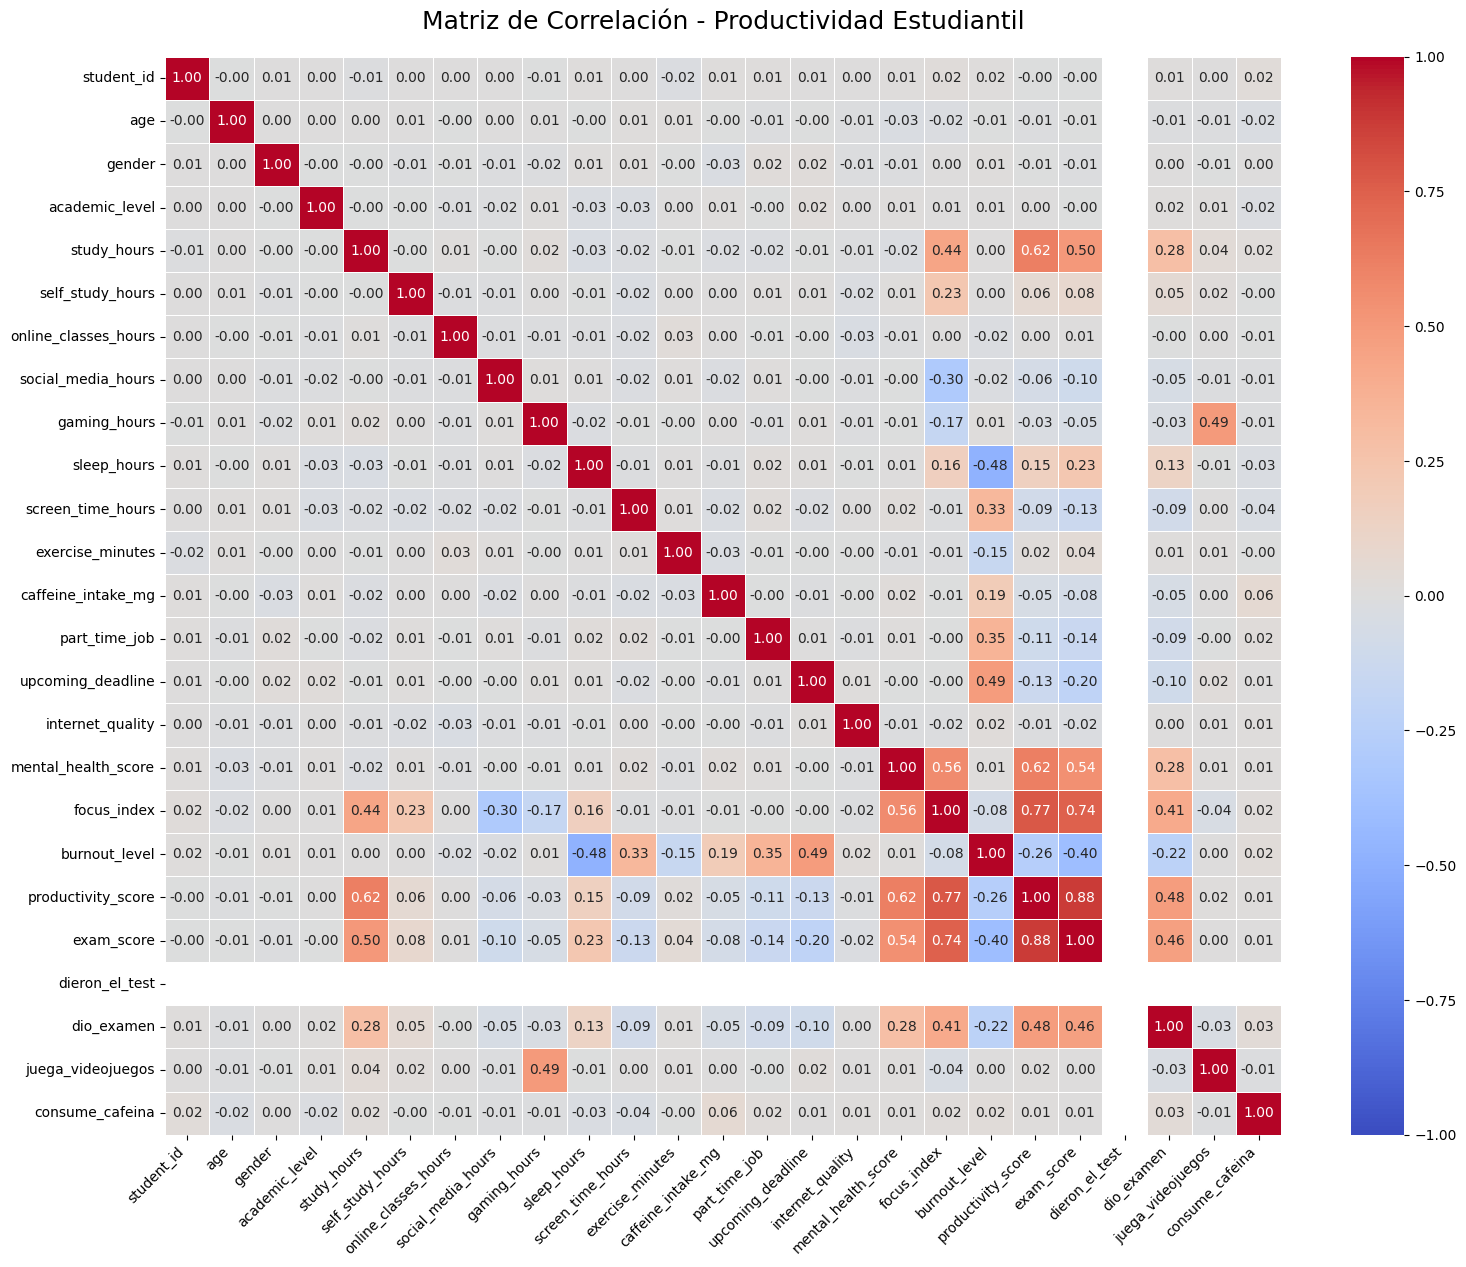

In [8]:
# Calculamos la matriz de correlación 
matriz_correlacion = df.corr()

# Configuramos el tamaño del gráfico para que se vea bien (es un dataset con muchas columnas)
plt.figure(figsize=(18, 14))

# Creamos el Heatmap (mapa de calor) usando Seaborn
sns.heatmap(matriz_correlacion, 
            annot=True,         # Muestra el valor numérico de la correlación en cada cuadro
            cmap='coolwarm',    # Usa colores azules para negativas y rojos para positivas
            fmt='.2f',          # Redondea los números a 2 decimales para que no se sature
            linewidths=0.5,     
            vmin=-1, vmax=1)    

# Agregamos el título y mostramos el gráfico
plt.title('Matriz de Correlación - Productividad Estudiantil', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right') # Rotamos las etiquetas del eje X para que no se superpongan
plt.show()


In [9]:
#  Calculamos la correlación específica de 'dio_examen' con todas las demás variables numéricas
correlaciones_examen = df.corr(numeric_only=True)['dio_examen'].sort_values(ascending=False)

# Imprimimos el resultado de forma ordenada
print("--- Correlación con la probabilidad de rendir (dio_examen) ---")
print(correlaciones_examen)


--- Correlación con la probabilidad de rendir (dio_examen) ---
dio_examen              1.000000
productivity_score      0.481826
exam_score              0.462213
focus_index             0.410052
mental_health_score     0.284187
study_hours             0.282251
sleep_hours             0.130713
self_study_hours        0.050040
consume_cafeina         0.034951
academic_level          0.015555
exercise_minutes        0.013291
student_id              0.011618
internet_quality        0.004049
gender                  0.002722
online_classes_hours   -0.000555
age                    -0.012373
juega_videojuegos      -0.033732
gaming_hours           -0.033800
caffeine_intake_mg     -0.047015
social_media_hours     -0.051804
screen_time_hours      -0.087049
part_time_job          -0.090116
upcoming_deadline      -0.095622
burnout_level          -0.223750
dieron_el_test               NaN
Name: dio_examen, dtype: float64


Luego de los análisis realizados, para la variable "dio_examen" se puede apreciar una alta correlación positiva con "productivity_score" (0.482), "exam_score" (0.462) y "focus_index" (0.410), y una correlación negativa a considerar en la variable "burnout_level" (-0.223), las variables "consume_cafeina" y "juega_videojuegos" tienen una baja correlación, aunque cabe resaltar el hecho de que la correlación entre "dio_examen" y "consume_cafeina" es muy ligeramente positiva, pero entre "dio_examen" y "caffeine_intake_mg" es minúsculamente negativa, esto podria deberse a que si bien la existencia de consumo de cafeína en si incrementa la probabilidad de rendir el examen, un consumo demasiado elevado podría tener un efecto contrario a lo indicado.

En cuanto a la correlación entre variables, se aprecia una correlación extremadamente positiva entre 
"exam_score":"productivity_score" (0.88),"productivity_score":"focus_index"(0.77),"focus_index":"exam_score" (0.74) y a su vez se aprecia correlación considerablemente negativa entre "burnout_level":"sleep_hours"(0.48), "burnout_level":"exam_score"(0.40), esto seguramente debido a que el nivel de agotamiento de un estudiante (mas agotamiento) probablemente deriva de pocas horas de sueño, y a su vez dicho agotamiento repercute en que el estudiante tenga menos probabilidades de asistir a rendir la evaluación, caso contrario entre variables como nivel de productividad y "exam_score" donde hace sentido que un mayor nivel de productividad se asocia a un mejor desempeño académico.

Posterior a esto se decidirá que variables podrian ser relevantes, las cuales son y las clasificamos:

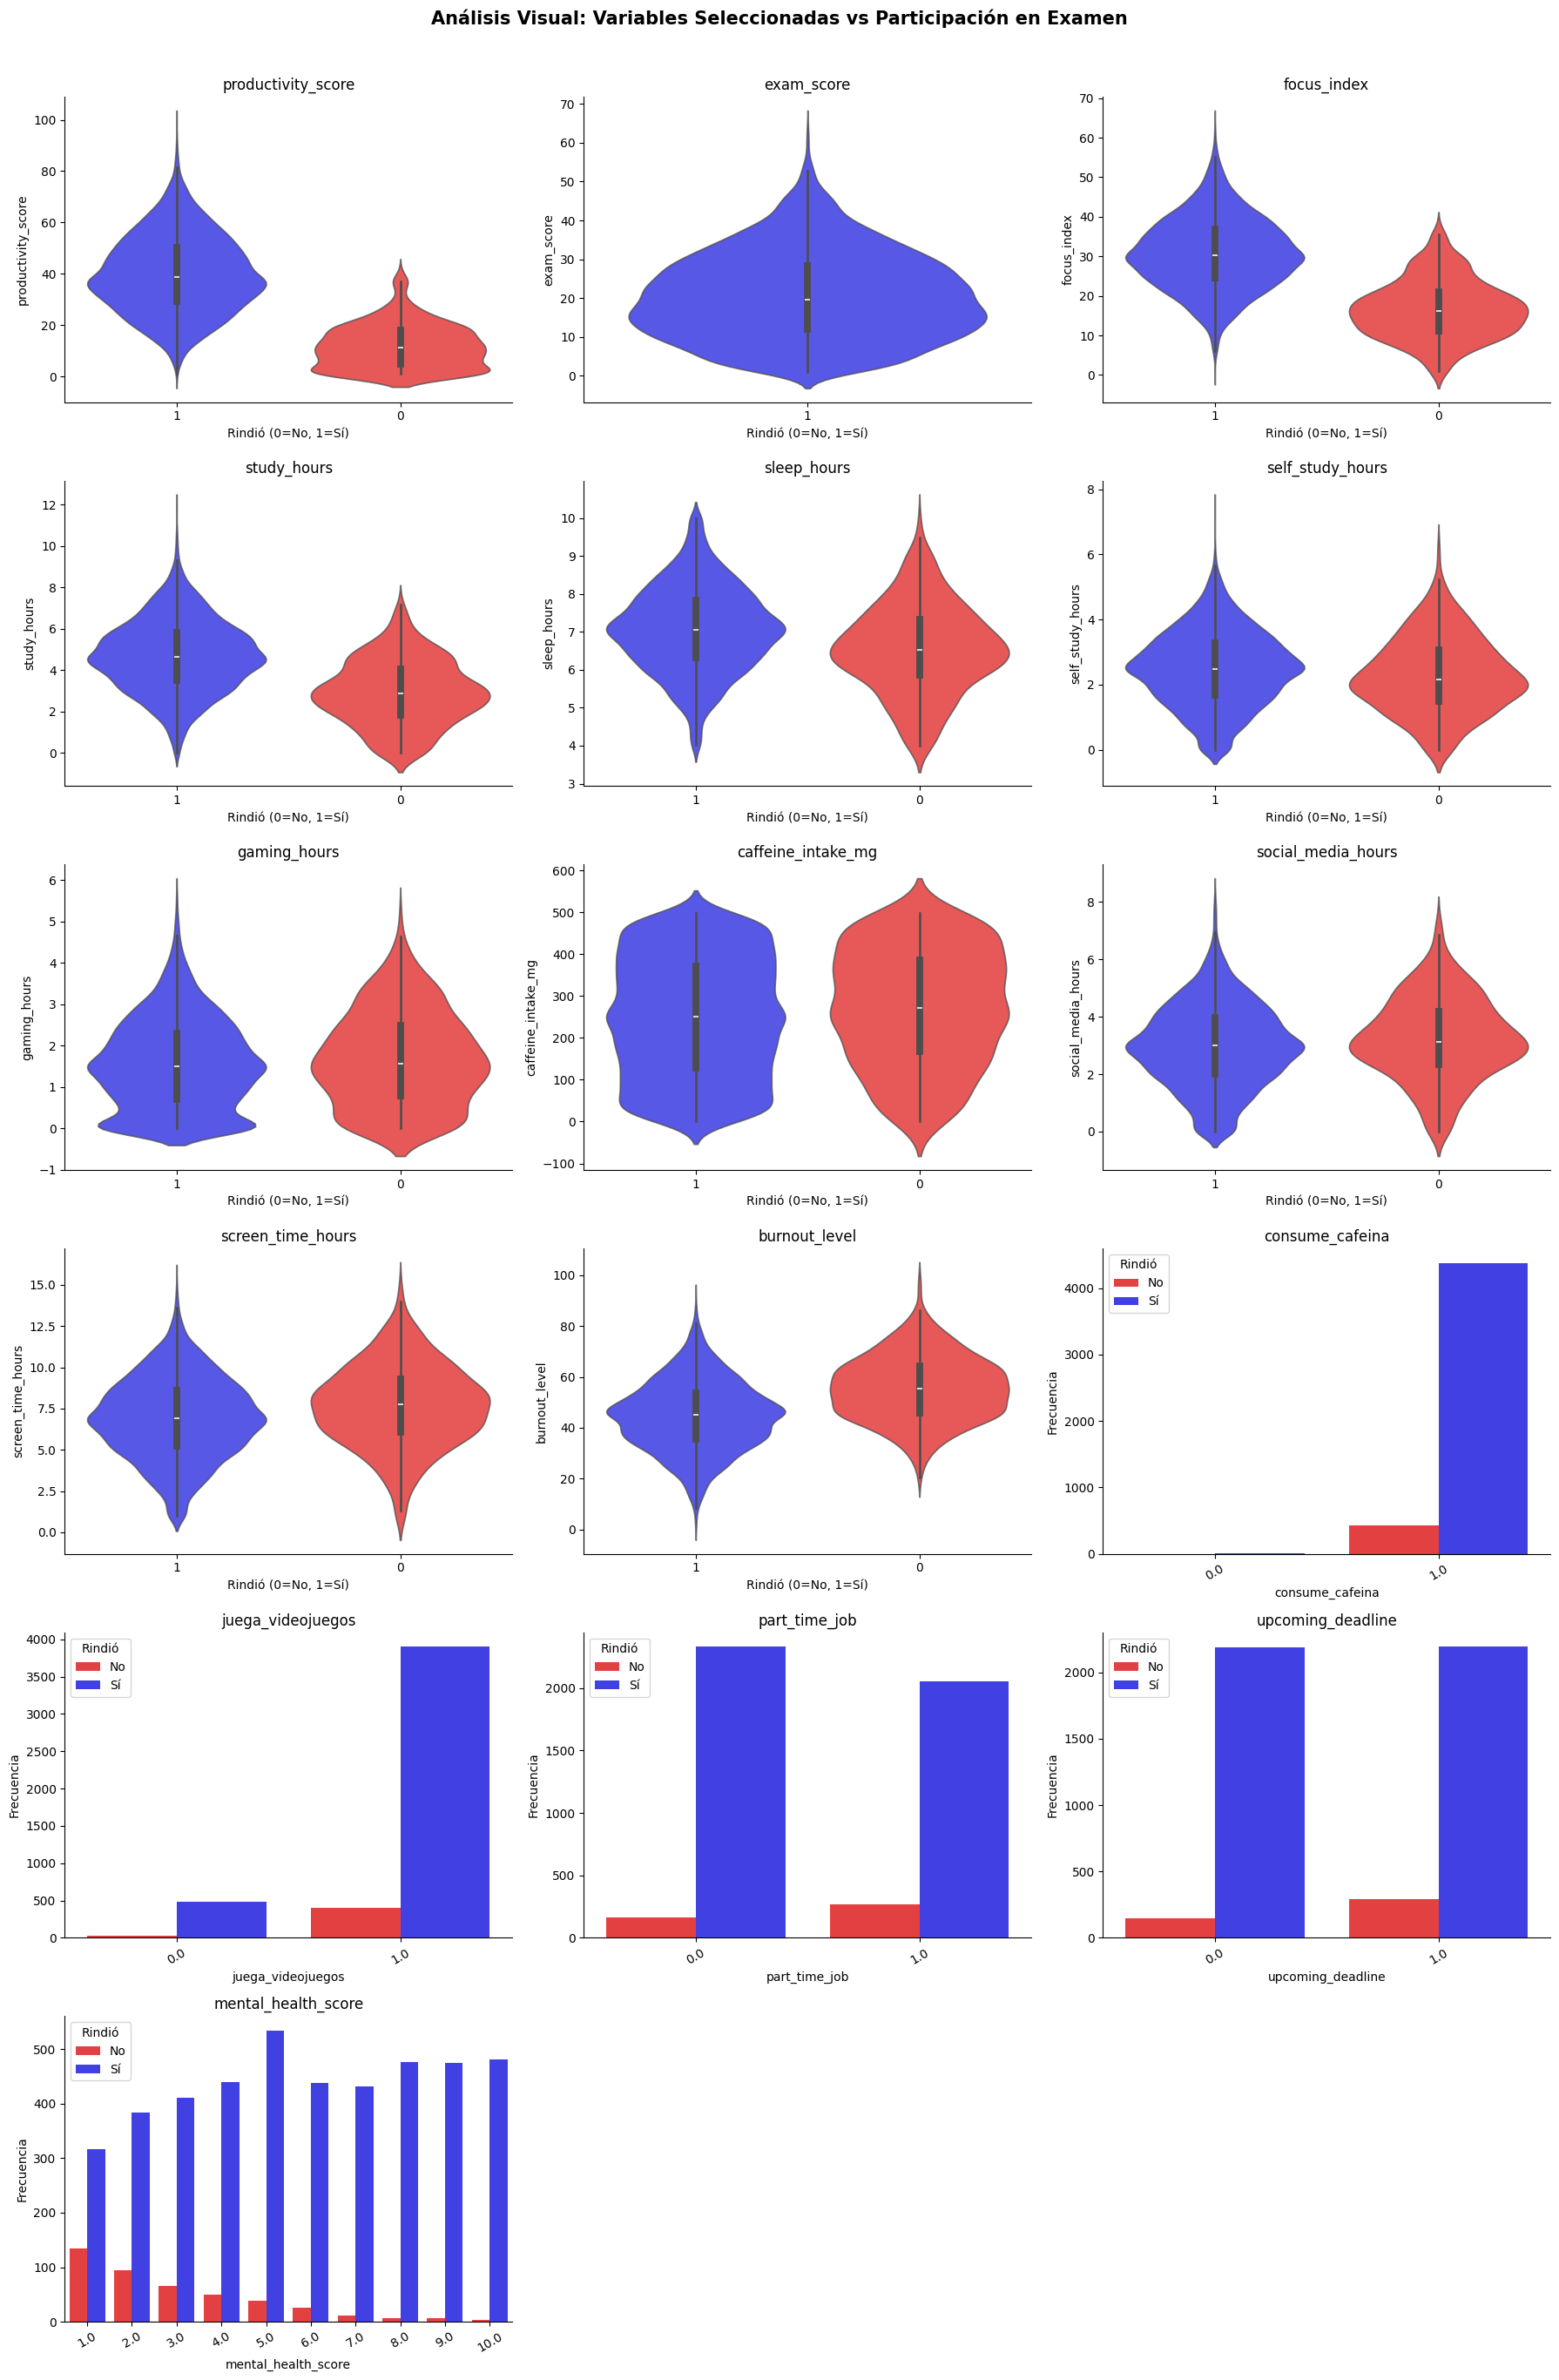

In [10]:
variables_continuas = [
    'productivity_score', 'exam_score', 'focus_index', 'study_hours', 'sleep_hours', 
    'self_study_hours', 'gaming_hours', 'caffeine_intake_mg', 
    'social_media_hours', 'screen_time_hours','burnout_level'
]

variables_categoricas = [
    'consume_cafeina', 'juega_videojuegos', 'part_time_job', 
    'upcoming_deadline', 'mental_health_score'
]

# Preparar subset con dio_examen valido
mask = df['dio_examen'].notna()
temp = df[mask].copy()
temp['dio_examen'] = temp['dio_examen'].astype(int).astype(str)

n_cols  = 3
n_total = len(variables_continuas) + len(variables_categoricas)
n_rows  = -(-n_total // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes = axes.flatten()
fig.suptitle('Análisis Visual: Variables Seleccionadas vs Participación en Examen',
             fontsize=15, fontweight='bold', y=1.01)

# Continuas
for i, var in enumerate(variables_continuas):
    temp_var = temp[temp['exam_score'] > 1] if var == 'exam_score' else temp
    sns.violinplot(
        data=temp_var, x='dio_examen', y=var, ax=axes[i],
        hue_order=['0', '1'], # <- Añadido para asegurar orden
        palette={'0': 'red', '1': 'blue'},
        alpha=0.75, inner='box'
    )
    axes[i].set(title=f'{var}', xlabel='Rindió (0=No, 1=Sí)', ylabel=var)

# Categóricas 
for j, var in enumerate(variables_categoricas):
    idx = len(variables_continuas) + j
    sns.countplot(
        data=temp, x=var, hue='dio_examen', ax=axes[idx],
        hue_order=['0', '1'], # <- Añadido para asegurar que 0 vaya antes que 1
        palette={'0': 'red', '1': 'blue'}, alpha=0.85
    )
    axes[idx].set(title=f'{var}', xlabel=var, ylabel='Frecuencia')
    axes[idx].tick_params(axis='x', rotation=30)
    
    handles, labels = axes[idx].get_legend_handles_labels()
    if handles:
        # Ahora sí, el orden está forzado, así que ['No', 'Sí'] será correcto
        axes[idx].legend(handles=handles, title='Rindió', labels=['No', 'Sí'])

# Apagar ejes sobrantes
for k in range(n_total, len(axes)):
    axes[k].set_visible(False)

sns.despine()
plt.tight_layout()
plt.show()


In [11]:
#Elegimos las siguientes variables para investigarlas.
variables = [
    'productivity_score', 'focus_index', 'study_hours', 'sleep_hours',
    'self_study_hours', 'gaming_hours', 'caffeine_intake_mg',
    'social_media_hours', 'screen_time_hours', 'burnout_level',
    'part_time_job', 'upcoming_deadline', 'mental_health_score', 'consume_cafeina',
    'juega_videojuegos'
]

#DataFrame con las estadísticas descriptivas de todas esas variables
stats = pd.DataFrame({var: df[var].describe() for var in variables}).round(2)

print(stats)

       productivity_score  focus_index  study_hours  sleep_hours  \
count             4818.00      4818.00      4818.00      4818.00   
mean                37.35        29.48         4.53         7.02   
std                 16.70         9.82         1.80         1.15   
min                  1.00         1.00         0.00         4.00   
25%                 25.61        22.80         3.29         6.27   
50%                 36.91        29.42         4.52         7.02   
75%                 48.97        36.10         5.74         7.80   
max                 98.02        63.48        11.84        10.00   

       self_study_hours  gaming_hours  caffeine_intake_mg  social_media_hours  \
count           4818.00       4818.00             4818.00             4818.00   
mean               2.48          1.57              250.88                3.00   
std                1.16          1.10              142.65                1.45   
min                0.00          0.00                0.00      

2. Ejecute un modelo de probabilidad lineal (*MCO*) que permita explicar la probabilidad de que un alumno rinda el examen, a partir de las informacion disponible. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [12]:
df_centrado = df.copy()

# Se centran las variables para una interpretacion mas clara en la regresion
for var in variables_continuas:
    df_centrado[var] = df_centrado[var] - df_centrado[var].mean()

In [13]:
# Se seleccionan las variables 
formula = '''dio_examen ~ productivity_score + focus_index + mental_health_score + study_hours + 
burnout_level + consume_cafeina + juega_videojuegos + C(academic_level, Treatment(reference=1))'''
# reference= 1 => High School es la categoría base

# Estimación con errores robustos
# HC1 corrige la heterocedasticidad inherente al tener Y binaria
modelo_mco = smf.ols(formula, data = df_centrado).fit(cov_type='HC1')
print(modelo_mco.summary())

                            OLS Regression Results                            
Dep. Variable:             dio_examen   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     82.69
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          2.93e-143
Time:                        14:39:25   Log-Likelihood:                -101.37
No. Observations:                4818   AIC:                             222.7
Df Residuals:                    4808   BIC:                             287.5
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

Observando los resultados del MCO se determina eliminar las variables study_hours y mental_health_score al ser poco significativas

In [14]:
formula2 = '''dio_examen ~ productivity_score + focus_index + 
burnout_level + consume_cafeina + juega_videojuegos + C(academic_level, Treatment(reference=1))'''
modelo_mco = smf.ols(formula2, data = df_centrado).fit(cov_type='HC1')
print(modelo_mco.summary())

                            OLS Regression Results                            
Dep. Variable:             dio_examen   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     106.2
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          4.85e-145
Time:                        14:39:25   Log-Likelihood:                -101.78
No. Observations:                4818   AIC:                             219.6
Df Residuals:                    4810   BIC:                             271.4
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [15]:
# Verificación de las predicciones fuera del rango [0,1] 
pred = modelo_mco.fittedvalues
n_fuera = ((pred < 0) | (pred > 1)).sum()
pct_fuera = n_fuera / len(pred) * 100
print(f"\nPredicciones fuera de [0,1]: {n_fuera} ({pct_fuera:.1f}%)")
print(f"Rango de predicciones: [{pred.min():.3f}, {pred.max():.3f}]")


Predicciones fuera de [0,1]: 1310 (27.2%)
Rango de predicciones: [0.347, 1.416]


Se eligieron las variables del modelo MCO en funcion a su correlación con "dio_examen" además de añadir las dos variables binarias que despertaron interés en un principio, luego en base a dichas variables se realizaron iteraciones donde en un primer lugar se determinó la existencia de bastantes variables poco significativas (study_hours y mental_health_score, con p>0.2) con lo cual fueron eliminadas y en la segunda iteración se llegó finalmente a un modelo con unicamente variables significativas bajo los criterios definidos.
Sobre el modelo final cabe resaltar que las probabilidades de que el estudiante asista a rendir el examen aumentan en un 0.6%  por cada punto de incremento en el nivel de productividad y 0.37% por el aumento de un punto en el indice de nivel de concentracion del estudiante, además de que el hecho de que el estudiante consuma cafeína incrementa dichas probabilidades en un 27.97%; por otra parte las probabilidades disminuyen en un 0.25% por cada punto de nivel de agotamiento que se incremente en el estudiante y el hecho de que este ultimo juegue videojuegos disminuye las probabilidades de asistencia en un 3.11%.
Con respecto al R2, este es de 0.251 y un 27.2% de las predicciones realizadas fueron fuera de rango, algo propio de las limitaciones del MCO.

3. Ejecute un modelo *probit* para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [16]:
probit = smf.probit(formula2, data = df_centrado).fit(cov_type='HC1')
print(probit.summary())

mfx = probit.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.127022
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:             dio_examen   No. Observations:                 4818
Model:                         Probit   Df Residuals:                     4810
Method:                           MLE   Df Model:                            7
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.5797
Time:                        14:39:26   Log-Likelihood:                -611.99
converged:                       True   LL-Null:                       -1456.2
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                       

Se estimó un modelo Probit lo que arrojó un Pseudo R² de 0.5797, considerablemente superior al R² de MCO, lo que hace sentido pues el modelo Probit captura mejor la naturaleza binaria de la variable dependiente que el modelo MCO.
En cuanto a los coeficientes, se interpretan de forma distinta al MCO: un incremento de un punto en productividad desplaza el índice z en 0.0949 desviaciones estándar, lo que se traduce en un incremento de 0.67 pp en la probabilidad dado por el dy/dx, así mismo con el resto de variables. Nos detendremos específicamente en consume_cafeina y juega_videojuegos, variables que mantienen su significancia pero sin embargo cambian sus efectos marginales sobre la predicción, disminuyendo su efecto sobre esta última. Por ejemplo, el hecho de que un estudiante consuma cafeína pasa de incrementar la probabilidad de asistencia en 27.97 pp a 8.69 pp, un incremento bastante menor pero significativo aún y mucho más confiable debido a la naturaleza del Probit que respeta bien los límites del intervalo [0,1].
Cabe señalar que el modelo advierte quasi-separación parcial, donde un 41% de las observaciones pueden ser perfectamente predichas. Esto ocurre probablemente por la variable consume_cafeina, cuya naturaleza binaria permite separar casi perfectamente algunos grupos de la muestra.

4. Ejecute un modelo *logit*  para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [17]:
logit = smf.logit(formula2, data = df_centrado).fit(cov_type = 'HC1')
print(logit.summary())

mfx2 = logit.get_margeff()
print(mfx2.summary())

Optimization terminated successfully.
         Current function value: 0.127171
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:             dio_examen   No. Observations:                 4818
Model:                          Logit   Df Residuals:                     4810
Method:                           MLE   Df Model:                            7
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.5792
Time:                        14:39:26   Log-Likelihood:                -612.71
converged:                       True   LL-Null:                       -1456.2
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                      

Siguiendo con el modelo Logit, se estimó un modelo que arrojó un Pseudo R² de 0.5792, aun más alto al R² del MCO y ligeramente menor al R² del Probit, los efectos de las variables binarias consume_cafeina y juega_videojuegos son similares a con el modelo Probit, con un coeficiente de 2.2596, un estudiante que consume cafeina tiene 9.58 veces más chances de rendir el examen que uno que no consume, y un estudiante que juega videojuegos reduce las chances de rendir a 0.637 veces las del estudiante que no juega, esto calculandolo en base a euler elevado al coeficiente.
Con respecto a la quasi-separación parcial, el modelo advierte que un 22% de las observaciones pueden ser predichas a la perfección, seguramente debido a la misma variable consume_cafeina mencionada en el item 3. 


5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

Los tres modelos coinciden en signo y significancia para las variables seleccionadas, las diferencias están en la magnitud de sus efectos. Las diferencias se explican por la forma en que funciona cada modelo. El MCO impone una relación lineal entre las variables y la probabilidad, sin restricción en el intervalo [0,1], los modelos Probit y Logit en cambio aplican funciones de transformación (normal estándar y logística) que comprimen las predicciones dentro de [0,1], produciendo efectos marginales más conservadores y realistas.
Los modelos Logit o Probit son más adecuados para realizar la predicción, ya que, la variable dependiente dio_examen es binaria, y estos modelos están diseñados específicamente para ese caso, sus predicciones respetan el intervalo [0,1] por construcción, a diferencia del MCO que puede predecir probabilidades negativas o mayores a 1 y sus Pseudo R² (0.5797 y 0.5792) son muy superior al R² del MCO (0.253), indicando mejor ajuste. 

6. Use un modelo Poisson para explicar la nota del examen, entre aquellos alumnos que lo rindieron. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [18]:
df_poisson = df[df['dio_examen'] == 1].copy()

df_poisson['exam_score_p'] = df_poisson['exam_score'].round(0).astype(int)

print(f'Rango de exam_score: [{df_poisson["exam_score_p"].min()}, {df_poisson["exam_score_p"].max()}]')
print(f"Observaciones: {len(df_poisson)}")

Rango de exam_score: [1, 64]
Observaciones: 4385


Trabajaremos bajo el supuesto de que las notas van de 1 a 70

In [19]:
correlaciones_nota = df_poisson.corr()['exam_score_p'].sort_values(ascending=False)
print("Correlación con la nota del examen (exam_score_p)")
print(correlaciones_nota)

Correlación con la nota del examen (exam_score_p)
exam_score_p            1.000000
exam_score              0.999676
productivity_score      0.857912
focus_index             0.707618
mental_health_score     0.493427
study_hours             0.454975
sleep_hours             0.204625
self_study_hours        0.069174
exercise_minutes        0.040971
juega_videojuegos       0.021547
online_classes_hours    0.006541
age                    -0.002041
student_id             -0.010997
academic_level         -0.013602
consume_cafeina        -0.014018
gender                 -0.016884
internet_quality       -0.023423
gaming_hours           -0.042141
caffeine_intake_mg     -0.064063
social_media_hours     -0.093171
screen_time_hours      -0.108982
part_time_job          -0.118056
upcoming_deadline      -0.188674
burnout_level          -0.357986
dieron_el_test               NaN
dio_examen                   NaN
Name: exam_score_p, dtype: float64


In [20]:
formula_p1 =  '''exam_score_p ~ productivity_score 
                                      + focus_index 
                                      + burnout_level 
                                      + study_hours
                                      + upcoming_deadline
                                      + mental_health_score
                                      + C(academic_level, Treatment(reference=1))'''

In [21]:
modelo_p = smf.poisson(formula_p1, data = df_poisson).fit(cov_type='HC1')
print(modelo_p.summary())

Optimization terminated successfully.
         Current function value: 3.233784
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:           exam_score_p   No. Observations:                 4385
Model:                        Poisson   Df Residuals:                     4376
Method:                           MLE   Df Model:                            8
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.4241
Time:                        14:39:26   Log-Likelihood:                -14180.
converged:                       True   LL-Null:                       -24621.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                       

Se estimó un modelo Poisson sobre la muestra de alumnos que rindieron el examen (n=4.385), utilizando como variable dependiente exam_score transformada a entero mediante redondeo, ya que Poisson requiere una variable de conteo. El modelo nos arroja un Pseudo R² de 0.4241 con todas sis variables significativas para 0.01>=p, Las variables seleccionadas fueron productivity_score, focus_index, burnout_level, study_hours, upcoming_deadline y mental_health_score, además de academic_level como variable categórica. Cabe mencionar que la unica variable poco significativa fue academic_level, lo que implica que el nivel de educación pierde relevancia a la hora de explicar el resultado en el examen.

7. Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.

In [22]:
#Sobredispersion en la data
Test=((df_poisson['exam_score_p']-modelo_p.predict())**2-modelo_p.predict())/modelo_p.predict()
TestO=sm.OLS(Test,modelo_p.predict()).fit()
print(TestO.summary())

                                 OLS Regression Results                                
Dep. Variable:           exam_score_p   R-squared (uncentered):                   0.047
Model:                            OLS   Adj. R-squared (uncentered):              0.047
Method:                 Least Squares   F-statistic:                              217.8
Date:                Wed, 22 Apr 2026   Prob (F-statistic):                    3.83e-48
Time:                        14:39:26   Log-Likelihood:                         -10012.
No. Observations:                4385   AIC:                                  2.003e+04
Df Residuals:                    4384   BIC:                                  2.003e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Una vez realizado el test este nos arrojó un coeficiente de 0.0228, positivo y altamente significativo (p < 0.001). Esto indica que la varianza de los datos excede lo que asumiría un modelo Poisson estándar con lo cual si existe sobredispersión en la data, siendo el alfa óptimo estimado de 0.0228.

8. Usando la informacion anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

In [23]:
binomial_neg = smf.negativebinomial(formula_p1, data=df_poisson).fit(cov_type='HC1', disp=False)
print(binomial_neg.summary())
#Efectos Marginales
mfx_nb = binomial_neg.get_margeff()
print(mfx_nb.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:           exam_score_p   No. Observations:                 4385
Model:               NegativeBinomial   Df Residuals:                     4376
Method:                           MLE   Df Model:                            8
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.1698
Time:                        14:39:26   Log-Likelihood:                -13909.
converged:                       True   LL-Null:                       -16753.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                                            1.9433      0.025     77.480      0.000       1.894       1.992
C(academic_level,

Se mantuvieron las variables utilizadas en el modelo Poisson y se pudo apreciar que todas son significantes aún, y sus efectos marginales son productivity_score (0.4182), focus_index (0.3107), burnout_level (-0.2074), study_hours (0.3488), upcoming_deadline (-0.6268) y mental_health_score (0.3082)
En cuanto al alfa, este es de (0.0317) con p<(0.001), la variable academic_level sigue sin ser significativa como en los otros modelos realizados y se aprecia que el Log-Likelihood mejora ligeramente con respecto a su valor en la Poisson lo que indica un mejor ajuste.

9. Comente los resultados obtenidos en 6, 7 y 8. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

Al comparar los modelos Poisson y Binomial Negativo, se observa que los signos, magnitudes y niveles de significancia de la mayoría de las variables son consistentes entre ambas especificaciones. Productivity_score, focus_index y mental_health_score presentan efectos positivos y estadísticamente significativos, mientras que burnout_level y upcoming_deadline muestran efectos negativos significativos en ambos modelos. Por su parte, la variable academic_level no resulta significativa en ninguna de las especificaciones.
Existen diferencias importantes en términos de ajuste y supuestos del modelo. El modelo Poisson presenta un pseudo R² mayor (0.4241), aunque no es comparable a su par del modelo Binomial Negativo, además de que el log-likelihood es más bajo (-14180) que en la Binomial Negativa (-13.909), sin mencionar que el test de dispersión indica claramente la presencia de sobredispersión. Esto nos dice que la varianza de la variable dependiente es mayor que su media, violando el supuesto principal del modelo Poisson. Estas diferencias existen debido a la sobredispersión de los datos en el modelo Poisson además de que los modelos manejan de forma distinta la varianza.
El modelo mas adecuado para responder la pregunta de investigación es el modelo Binomial Negativo, ya que reconoce y modela la sobredispersión, mejora el ajuste global (log-likelihood más alto)y evita sesgos en los errores estándar y en la significancia de los coeficientes que el Poisson subestima.
Con respecto a que variables resultaron ser robustas, cabe resaltar las variables productivity_score, focus_index, study_hours y mental_health_score con efecto positivo y las variables burnout_level y upcoming_deadline con efecto negativo.